In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/Clean_BNPParibas_Data.csv")

print(df.shape)

display(df.head())

(911, 10)


,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0
4,6,25,17,53.02,850.81,Two Year,DSL,0,Cash,0


In [3]:
X_cluster = df.drop(
    columns=[
        "customer_id",
        "contract_type"
    ]
)

In [4]:
numeric_features = X_cluster.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_cluster.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'support_tickets', 'churn']

Categorical features:
['internet_service', 'payment_method']


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

hierarchical_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_hierarchical = hierarchical_preprocessor.fit_transform(X_cluster)

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(
    X_hierarchical,
    method="ward"
)

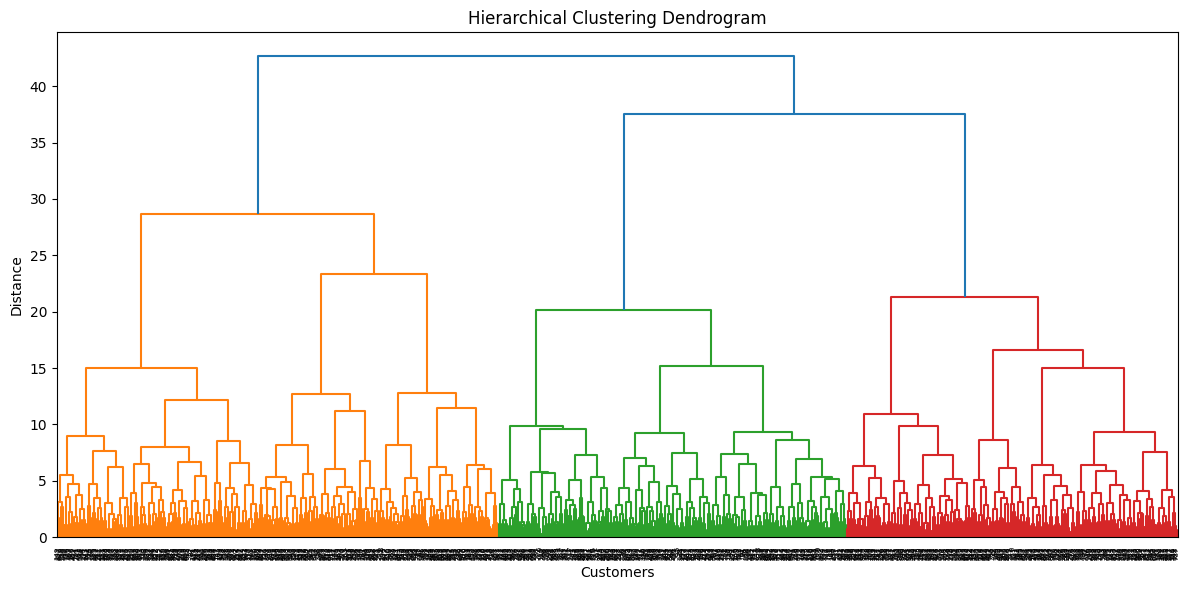

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix
)

plt.xlabel("Customers")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_hierarchical
)

In [10]:
hierarchical_df = df.copy()

hierarchical_df["Cluster"] = hierarchical_labels

display(hierarchical_df.head())

,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn,Cluster
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1,1
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1,0
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0,2
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0,2
4,6,25,17,53.02,850.81,Two Year,DSL,0,Cash,0,2


In [11]:
hierarchical_summary = (
    hierarchical_df
    .groupby("Cluster")[numeric_features]
    .mean()
)

display(hierarchical_summary)

,age,tenure_months,monthly_charges,total_charges,support_tickets,churn
Cluster,,,,,,
0,44.398329,51.261838,94.116323,4743.584095,2.125348,0.543175
1,44.929368,17.988848,86.616617,1544.033457,1.966543,0.996283
2,41.982332,31.293286,55.051237,1388.590565,1.681979,0.000000


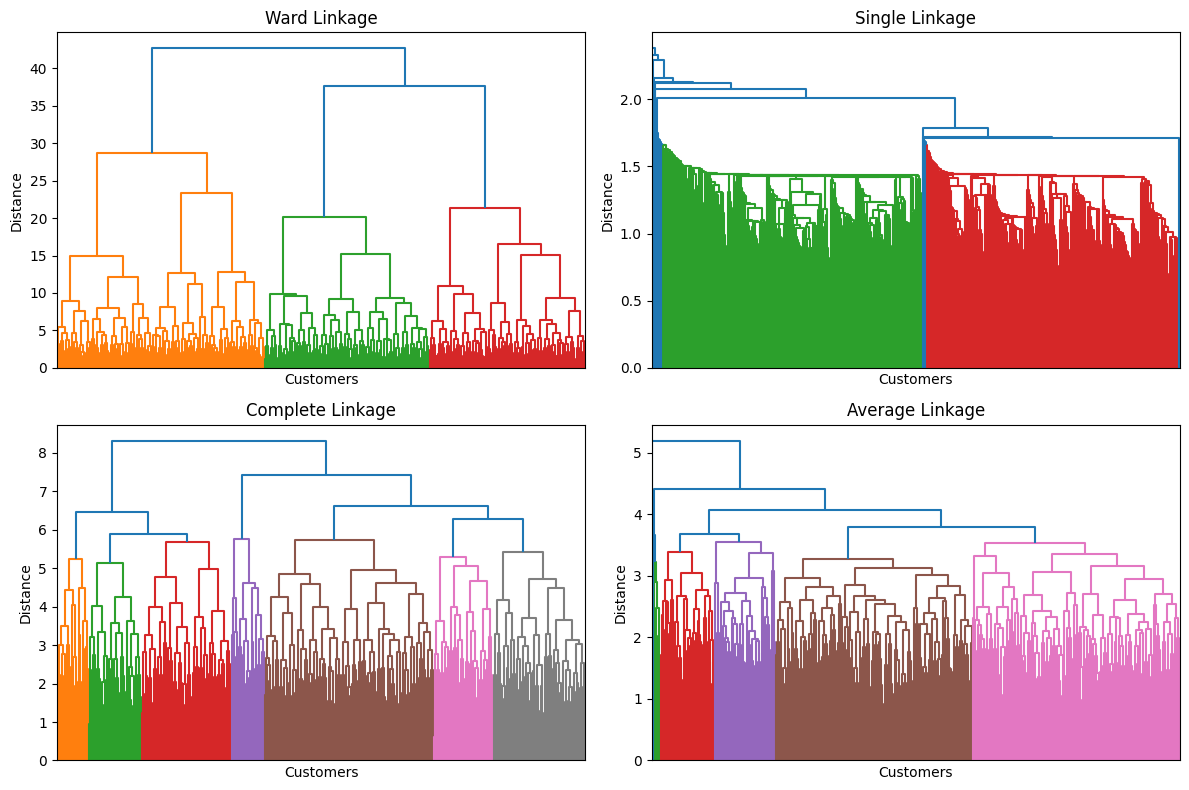

In [12]:
methods = [
    "ward",
    "single",
    "complete",
    "average"
]

plt.figure(figsize=(12, 8))

for i, method in enumerate(methods, 1):

    linkage_matrix = linkage(
        X_hierarchical,
        method=method
    )

    plt.subplot(2, 2, i)

    dendrogram(
        linkage_matrix,
        no_labels=True
    )

    plt.title(
        f"{method.capitalize()} Linkage"
    )

    plt.xlabel("Customers")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    X_hierarchical,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    hierarchical_silhouette
)

Hierarchical Clustering Silhouette Score: 0.13131898945842876


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_hierarchical)

In [15]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": hierarchical_labels
})

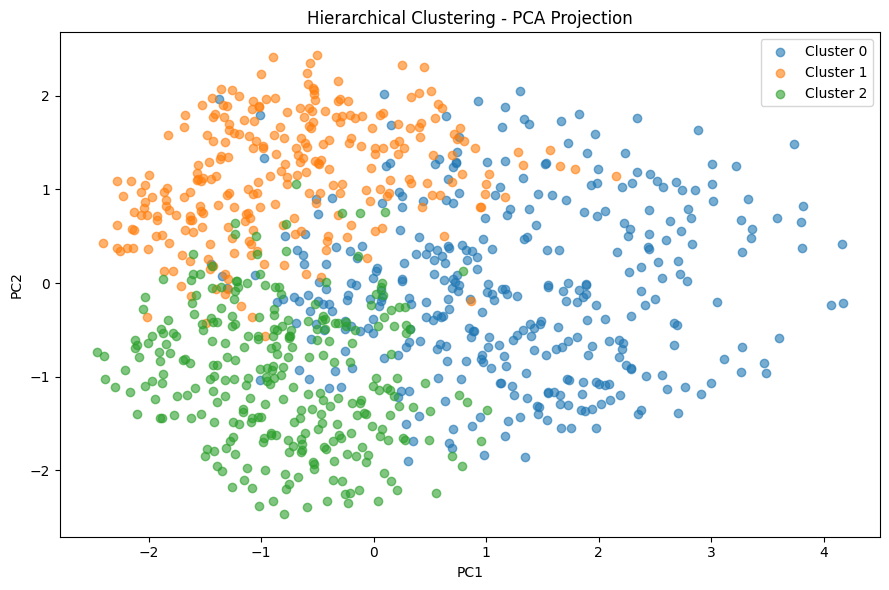

In [16]:
plt.figure(figsize=(9, 6))

for cluster in sorted(
    pca_df["Cluster"].unique()
):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "Hierarchical Clustering - PCA Projection"
)

plt.legend()

plt.tight_layout()
plt.show()